# Coloreado de Grafos con CSP: BT-FC-DO

Este notebook resuelve el problema de **coloreado de grafos** modelado como un
**Problema de Satisfaccion de Restricciones (CSP)**:

- **Variables**: cada nodo del grafo
- **Dominio**: los colores disponibles (1, 2, ..., K)
- **Restriccion**: dos nodos conectados por una arista no pueden tener el mismo color

El algoritmo usado se llama **BT-FC-DO**:

- **BT (Backtracking)**: se prueba un color, si falla se retrocede y se prueba otro
- **FC (Forward Checking)**: al colorear un nodo, se elimina ese color de los dominios
  de sus vecinos no coloreados; si algun vecino se queda sin opciones, se detecta el
  fallo de inmediato, sin seguir bajando en el arbol de busqueda
- **DO (Ordenamiento Dinamico)**: en vez de recorrer los nodos en un orden fijo, se elige
  dinamicamente:
  - que nodo colorear primero -> el mas restringido (menos colores disponibles, **MRV**)
  - que color probar primero -> el que menos restringe a los vecinos (**LCV**)

**Entrada**: matriz de adyacencia NxN (N < 21), simetrica, 1 = conectado, 0 = no conectado.
Se puede leer desde un archivo `.txt` o generar aleatoriamente.

**Salida**: el grafo dibujado con sus nodos coloreados (se muestra directamente aqui abajo).

In [1]:
import random
import networkx as nx
import matplotlib.pyplot as plt

## 1) Obtener el grafo

Dos formas de conseguir la matriz de adyacencia:

- `leer_grafo_archivo(ruta)`: lee un archivo `.txt` con el formato:
  - primera linea: N (numero de nodos)
  - siguientes N lineas: N valores (0 o 1) separados por espacios
- `generar_grafo_aleatorio(n, prob_arista, semilla)`: genera una matriz simetrica al azar.

In [2]:
def leer_grafo_archivo(ruta):
    """Lee N y la matriz NxN desde un .txt: 1ra linea = N, luego N filas de 0/1."""
    with open(ruta, "r", encoding="utf-8") as f:
        datos = f.read().split()
    n = int(datos[0])
    valores = datos[1:1 + n * n]
    return [[int(valores[i * n + j]) for j in range(n)] for i in range(n)], n


def generar_grafo_aleatorio(n, prob_arista=0.3, semilla=None):
    """Genera una matriz de adyacencia NxN simetrica al azar."""
    if semilla is not None:
        random.seed(semilla)
    m = [[0] * n for _ in range(n)]
    for i in range(n):
        for j in range(i + 1, n):
            if random.random() < prob_arista:
                m[i][j] = m[j][i] = 1
    return m

## 2) Algoritmo BT-FC-DO

- `variable_mas_restringida`: heuristica **MRV**, elige el nodo no asignado con menos
  colores posibles en su dominio.
- `ordenar_valores`: heuristica **LCV**, ordena los colores probando primero el que
  menos restringe a los vecinos no asignados.
- `forward_checking`: quita el color recien asignado del dominio de los vecinos no
  asignados; si algun dominio queda vacio, se detecta el fallo de inmediato.
- `backtrack`: la recursion de backtracking, apoyada en FC y DO.
- `resolver_coloreado`: prueba K = 1, 2, 3, ... hasta encontrar el minimo numero de
  colores con el que el grafo es coloreable.

In [3]:
def variable_mas_restringida(dominios, asignacion):
    """DO (variables) - MRV: elige el nodo no asignado con menos colores posibles.
    + Degree heuristic como desempate."""
    no_asignadas = [
        v for v in dominios
        if v not in asignacion
    ]

    return min(
        no_asignadas,
        key=lambda v: (
            len(dominios[v]),

            # Negativo porque min() busca el menor valor,
            # pero queremos el mayor número de vecinos.
            -sum(
                1
                for vecino in range(n)
                if matriz[v][vecino] == 1
                and vecino not in asignacion
            )
        )
    )

def ordenar_valores(nodo, dominios, matriz, n, asignacion):
    """DO (valores) - LCV: prueba primero el color que menos restringe a los vecinos."""
    def impacto(color):
        return sum(
            1 for v in range(n)
            if matriz[nodo][v] == 1 and v not in asignacion and color in dominios[v]
        )
    return sorted(dominios[nodo], key=impacto)


def forward_checking(matriz, n, nodo, color, dominios, asignacion):
    """FC: quita 'color' del dominio de los vecinos no asignados. Detecta dominios vacios."""
    eliminados = []
    for vecino in range(n):
        if matriz[nodo][vecino] == 1 and vecino not in asignacion and color in dominios[vecino]:
            dominios[vecino].remove(color)
            eliminados.append((vecino, color))
            if not dominios[vecino]:
                return False, eliminados
    return True, eliminados


def backtrack(matriz, n, dominios, asignacion, orden_coloreado):
    """BT: backtracking recursivo apoyado en FC y DO."""
    if len(asignacion) == n:
        return dict(asignacion)

    nodo = variable_mas_restringida(dominios, asignacion)
    for color in ordenar_valores(nodo, dominios, matriz, n, asignacion):
        asignacion[nodo] = color
        orden_coloreado.append(nodo)
        ok, eliminados = forward_checking(matriz, n, nodo, color, dominios, asignacion)
        if ok:
            resultado = backtrack(matriz, n, dominios, asignacion, orden_coloreado)
            if resultado is not None:
                return resultado
        for vecino, c in eliminados:            # deshacer FC
            dominios[vecino].add(c)
        del asignacion[nodo]
        orden_coloreado.pop()

    return None


def resolver_coloreado(matriz, n, k_max=None):
    """Prueba K = 1, 2, 3... hasta encontrar el minimo numero de colores que funcione."""
    for k in range(1, (k_max or n) + 1):
        dominios = {i: set(range(1, k + 1)) for i in range(n)}
        orden_coloreado = []
        resultado = backtrack(matriz, n, dominios, {}, orden_coloreado)
        if resultado is not None:
            return resultado, k, orden_coloreado
    return None, None, None

## 3) Visualizacion

Dibuja el grafo con `networkx` y colorea cada nodo segun la asignacion encontrada.
`plt.show()` hace que la figura se muestre directamente debajo de la celda.

In [4]:
def graficar_grafo_coloreado(matriz, n, asignacion, k):
    G = nx.Graph()
    G.add_nodes_from(range(n))
    for i in range(n):
        for j in range(i + 1, n):
            if matriz[i][j] == 1:
                G.add_edge(i, j)

    cmap = plt.get_cmap("tab20", max(k, 1))
    colores = [cmap((asignacion[i] - 1) % 20) for i in range(n)]

    plt.figure(figsize=(7, 7))
    nx.draw(
        G, nx.spring_layout(G, seed=42), with_labels=True,
        node_color=colores, node_size=700, edgecolors="black", font_weight="bold",
    )
    plt.title(f"Coloreado de grafo - {k} colores")
    plt.axis("off")
    plt.show()          # muestra el grafo directamente en el notebook

## 4) Programa principal

Cambia `MODO` a `"archivo"` (para leer tu propia matriz desde un `.txt`) o
`"aleatorio"` (para generar un grafo al azar).

- Si usas `"archivo"`, ajusta `ARCHIVO_ENTRADA` con la ruta de tu archivo (puede ser una ruta completa, por
ejemplo `C:\\Users\\tu_usuario\\Downloads\\grafo_entrada.txt`).

- Si usas `"aleatorio"`, puedes ajustar `n` para cambiar el número de nodos, `prob_arista` para cambiar la probabilidad de conexión y `semilla` para generar un grafo aleatorio diferente.

Solucion encontrada con 3 colores:
  Nodo 2 -> Color 1
  Nodo 3 -> Color 2
  Nodo 1 -> Color 3
  Nodo 4 -> Color 3
  Nodo 0 -> Color 2
  Nodo 5 -> Color 1


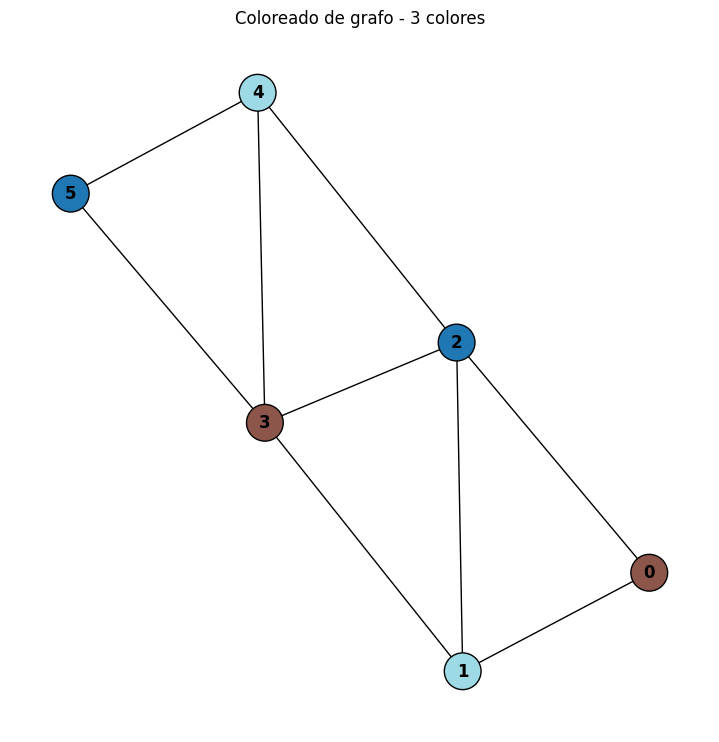

In [5]:
MODO = "archivo"                       # "archivo" o "aleatorio"
ARCHIVO_ENTRADA = "grafo_entrada.txt"  # usa la ruta completa si el archivo no esta en esta carpeta

if MODO == "archivo":
    matriz, n = leer_grafo_archivo(ARCHIVO_ENTRADA)
else:
    n = 10
    matriz = generar_grafo_aleatorio(n, prob_arista=0.35, semilla=7)

assert n < 21, "N debe ser menor a 21"

asignacion, k_usado, orden_coloreado = resolver_coloreado(matriz, n)

if asignacion is not None:
    print(f"Solucion encontrada con {k_usado} colores:")
    for posicion, nodo in enumerate(orden_coloreado, start=1):
        print(f"  Nodo {nodo} -> Color {asignacion[nodo]}")
    graficar_grafo_coloreado(matriz, n, asignacion, k_usado)
else:
    print("No se encontro solucion.")